# 03 — FINAL: Du bao gia MG95 — Toan bo mo hinh (src + notebook 2)

Notebook **cuoi cung**, gop tat ca mo hinh:

| Nhom | Mo hinh |
|---|---|
| Thong ke | **SARIMA**, **ARIMAX** (one-step-ahead) |
| Hybrid moi | **Jump-Gated ARIMAX-CatBoost** |
| Tuyen tinh | **Ridge / Linear Regression** |
| Phan loai huong | **Logistic Regression** (Accuracy / F1) |
| Cay | **LightGBM** (src baseline) |
| Deep Learning (Keras) | **LSTM**, **iTransformer** (src), **GUMNet-Lite** (src), **GUMNet-Ultra** (src) |
| Deep Learning (PyTorch) | **PatchTST**, **TFT** (neuralforecast) |

- Du lieu: `clean_data_exo_ver1.csv` + (tuy chon) **news sentiment** (`daily_features.csv`, auto-join theo ngay, 0-fill).
- Danh gia: **MAE, MAPE, SMAPE, R2** (+ RMSE), tat ca **one-step-ahead (H=1)** tren cung khung thoi gian test.
- DL Keras/PyTorch tu dong **skip** neu thieu thu vien (in huong dan cai dat) — notebook khong bao gio crash.

> Cau hinh trong CONFIG. Tang `dl_epochs` / `nf_steps` de chinh xac hon; doi `horizon` de test H=5/10.

In [1]:
# === Setup ===
import os
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")   # repo models use Keras-2 API (TF 2.17 ships Keras 3)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# Cai dat neu thieu:
# pip install lightgbm statsmodels scikit-learn tensorflow neuralforecast catboost

CONFIG = {
    "target":      "MG95",
    "horizon":     1,
    "seq_len":     30,
    "train_ratio": 0.80,
    "val_ratio":   0.10,
    "exog_cols":   ["WTI", "USD_Index", "GPR", "BRT DTD", "Brent_EU_Daily"],
    "seasonal":    5,
    "dl_epochs":   40,     # epochs cho LSTM/iTransformer/GUMNet (tang de tot hon)
    "nf_steps":    300,    # max_steps cho PatchTST/TFT
    "tune_lgbm":   False,
}
print("ROOT =", ROOT)
print("CONFIG =", CONFIG)

ROOT = e:\PCDOC\xangdau\XANG_DAU_FORECAST\XANG_DAU_FORECAST
CONFIG = {'target': 'MG95', 'horizon': 1, 'seq_len': 30, 'train_ratio': 0.8, 'val_ratio': 0.1, 'exog_cols': ['WTI', 'USD_Index', 'GPR', 'BRT DTD', 'Brent_EU_Daily'], 'seasonal': 5, 'dl_epochs': 40, 'nf_steps': 300, 'tune_lgbm': False}


## 1. Load du lieu exogenous + (tuy chon) News

In [2]:
from src.data_loader import load_and_engineer

TARGET = CONFIG["target"]
df = load_and_engineer()
print("Exo data:", df.shape, "|", df.index.min().date(), "->", df.index.max().date())

news_path = ROOT / "news-crawler" / "data" / "daily_features.csv"
news_cols = []
if news_path.exists():
    news = pd.read_csv(news_path, parse_dates=["date"]).set_index("date")
    news = news[~news.index.duplicated(keep="last")].sort_index()
    df = df.join(news, how="left")
    news_cols = list(news.columns)
    df[news_cols] = df[news_cols].fillna(0.0)
    cov = (df[news_cols].abs().sum(axis=1) > 0).mean() * 100
    print(f"News joined: +{len(news_cols)} cot | phu song ~{cov:.1f}% so ngay")
else:
    print("Khong co daily_features.csv -> chay khong co news (crawl -> sentiment.py -> aggregate.py de tao).")
print("Tong features:", len([c for c in df.columns if c != TARGET]))

Exo data: (4619, 52) | 2008-06-12 -> 2026-05-08
News joined: +16 cot | phu song ~0.0% so ngay
Tong features: 67


## 2. Chi so — MAE, RMSE, MAPE, SMAPE, R2 (+ phan loai)

In [3]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score)

def reg_metrics(y_true, y_pred, name):
    yt = np.asarray(y_true, float); yp = np.asarray(y_pred, float)
    mae  = mean_absolute_error(yt, yp)
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mape = float(np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-8))) * 100)
    smape = float(np.mean(2.0 * np.abs(yp - yt) / (np.abs(yt) + np.abs(yp) + 1e-8)) * 100)
    return {"Model": name, "MAE": round(mae,4), "RMSE": round(rmse,4),
            "MAPE(%)": round(mape,4), "SMAPE(%)": round(smape,4),
            "R2": round(float(r2_score(yt, yp)),4)}

def clf_metrics(y_true, y_pred, name):
    return {"Model": name,
            "Accuracy": round(float(accuracy_score(y_true, y_pred)),4),
            "F1": round(float(f1_score(y_true, y_pred, zero_division=0)),4)}

results = []
clf_results = []
print("Metrics ready.")

Metrics ready.


## 3. Du lieu dang BANG (cho ARIMA/Ridge/Logistic/LightGBM)
Chronological split, RobustScaler fit **chi tren train**.

In [4]:
from sklearn.preprocessing import RobustScaler

H = CONFIG["horizon"]
feature_cols = [c for c in df.columns if c != TARGET]

work = df.copy()
work["__y"] = work[TARGET].shift(-H)
work = work.dropna(subset=["__y"])

n   = len(work)
ntr = int(n * CONFIG["train_ratio"])
nvl = int(n * CONFIG["val_ratio"])
tr, vl, te = work.iloc[:ntr], work.iloc[ntr:ntr+nvl], work.iloc[ntr+nvl:]

scaler_X = RobustScaler().fit(tr[feature_cols])
Xtr = scaler_X.transform(tr[feature_cols])
Xvl = scaler_X.transform(vl[feature_cols])
Xte = scaler_X.transform(te[feature_cols])
ytr, yvl, yte = tr["__y"].values, vl["__y"].values, te["__y"].values
test_dates = te.index

dir_tr = (tr["__y"].values > tr[TARGET].values).astype(int)
dir_te = (te["__y"].values > te[TARGET].values).astype(int)

print(f"Features: {len(feature_cols)} (news: {len(news_cols)}) | Train {len(tr)} | Val {len(vl)} | Test {len(te)}")
print(f"Test period: {test_dates.min().date()} -> {test_dates.max().date()} | up-rate={dir_te.mean():.3f}")

Features: 67 (news: 16) | Train 3694 | Val 461 | Test 463
Test period: 2024-07-24 -> 2026-05-07 | up-rate=0.544


## 4. Du lieu dang CHUOI (sliding window) — dung chung cho LSTM / iTransformer / GUMNet

In [5]:
from src.data_loader import make_windows

SEQ = CONFIG["seq_len"]
n_df = len(df); ntr_df = int(n_df * CONFIG["train_ratio"])
scaler_y = RobustScaler().fit(df[[TARGET]].iloc[:ntr_df])     # scale y tren train

X_all = scaler_X.transform(df[feature_cols].values)
y_all = scaler_y.transform(df[[TARGET]].values).flatten()

Xw, yw = make_windows(X_all, y_all, time_steps=SEQ, horizon=H)
nW = len(Xw); a = int(nW * 0.8); b = int(nW * 0.1)
Xw_tr, Xw_vl, Xw_te = Xw[:a], Xw[a:a+b], Xw[a+b:]
yw_tr, yw_vl, yw_te = yw[:a], yw[a:a+b], yw[a+b:]
N_FEAT = len(feature_cols)

def eval_seq_model(model, name):
    pred = scaler_y.inverse_transform(np.asarray(model.predict(Xw_te, verbose=0)).reshape(-1,1)).flatten()
    ytru = scaler_y.inverse_transform(yw_te.reshape(-1,1)).flatten()
    results.append(reg_metrics(ytru, pred, name))
    print(results[-1])

print(f"Windows: train {Xw_tr.shape} | val {Xw_vl.shape} | test {Xw_te.shape}")

Windows: train (3671, 30, 67) | val (458, 30, 67) | test (460, 30, 67)


## 5. ARIMAX & SARIMA (one-step-ahead)

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_cols = [c for c in CONFIG["exog_cols"] if c in df.columns]
y_full  = df[TARGET].reset_index(drop=True).astype(float)
ex_full = df[exog_cols].reset_index(drop=True).astype(float)
N = len(y_full); n_test = len(te); split = N - n_test
y_te_arima = y_full.iloc[split:].values
arima_dates = df.index[split:]

try:
    res = SARIMAX(y_full.iloc[:split], exog=ex_full.iloc[:split], order=(2,1,2),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
    res2 = res.append(y_full.iloc[split:], exog=ex_full.iloc[split:], refit=False)
    pred_ax = res2.predict(start=split, end=N-1, exog=ex_full.iloc[split:]).values
    results.append(reg_metrics(y_te_arima, pred_ax, "ARIMAX")); print("ARIMAX:", results[-1])
except Exception as e:
    pred_ax = None; print("ARIMAX skipped:", e)

try:
    res_s = SARIMAX(y_full.iloc[:split], order=(1,1,1), seasonal_order=(1,0,1,CONFIG["seasonal"]),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
    res_s2 = res_s.append(y_full.iloc[split:], refit=False)
    pred_sa = res_s2.predict(start=split, end=N-1).values
    results.append(reg_metrics(y_te_arima, pred_sa, "SARIMA")); print("SARIMA:", results[-1])
except Exception as e:
    print("SARIMA skipped:", e)

c:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMAX: {'Model': 'ARIMAX', 'MAE': 1.4309, 'RMSE': 2.8246, 'MAPE(%)': 1.4613, 'SMAPE(%)': 1.4594, 'R2': 0.975}
SARIMA: {'Model': 'SARIMA', 'MAE': 1.5087, 'RMSE': 3.0464, 'MAPE(%)': 1.552, 'SMAPE(%)': 1.5508, 'R2': 0.9709}


## 6. Jump-Gated ARIMAX-CatBoost

Model tot nhat tu notebook model: ARIMAX du bao nen, CatBoost sua sai so, sau do them cong phu nhan dien ngay gia nhay manh. Section nay chi tao feature trong bo nho va append ket qua vao bang final.

In [ ]:
try:
    from src.models.jump_gated_arimax_catboost import (
        JumpGatedConfig,
        run_jump_gated_arimax_catboost,
    )

    jump_cfg = JumpGatedConfig(
        target=TARGET,
        horizon=H,
        train_ratio=CONFIG["train_ratio"],
        val_ratio=CONFIG["val_ratio"],
        exog_cols=CONFIG["exog_cols"],
        arimax_order=(2, 1, 2),
    )
    jump_result = run_jump_gated_arimax_catboost(
        load_and_engineer(target_col=TARGET),
        root=ROOT,
        config=jump_cfg,
        progress=True,
    )
    jump_row = jump_result["metrics"].query('Model == "Jump-Gated ARIMAX-CatBoost"').iloc[0].to_dict()
    results.append({k: jump_row[k] for k in ["Model", "MAE", "RMSE", "MAPE(%)", "SMAPE(%)", "R2"]})
    print("Jump-Gated ARIMAX-CatBoost:", results[-1])
except Exception as e:
    jump_result = None
    print("Jump-Gated ARIMAX-CatBoost skipped:", repr(e))

## 6. Ridge / Linear Regression

In [7]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0).fit(Xtr, ytr)
pred_ridge = ridge.predict(Xte)
results.append(reg_metrics(yte, pred_ridge, "Ridge (Linear)")); print(results[-1])

{'Model': 'Ridge (Linear)', 'MAE': 1.577, 'RMSE': 3.1661, 'MAPE(%)': 1.5319, 'SMAPE(%)': 1.5493, 'R2': 0.9685}


## 7. Logistic Regression — phan loai huong (tang/giam)

In [8]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, dir_tr)
clf_results.append(clf_metrics(dir_te, clf.predict(Xte), "LogisticRegression (huong)"))
print(clf_results[-1], "| baseline up-rate =", round(dir_te.mean(),3))

{'Model': 'LogisticRegression (huong)', 'Accuracy': 0.6112, 'F1': 0.5735} | baseline up-rate = 0.544


## 8. LightGBM (src baseline)

In [9]:
import lightgbm as lgb
if CONFIG["tune_lgbm"]:
    from src.models.baseline_lgbm import tune_lgbm, train_lgbm
    bp = tune_lgbm(Xtr, ytr, Xvl, yvl, n_trials=40)["best_params"]
    lgbm = train_lgbm(Xtr, ytr, Xvl, yvl, bp)
else:
    lgbm = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, max_depth=7,
                             num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                             min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1)
    lgbm.fit(Xtr, ytr, eval_set=[(Xvl, yvl)], callbacks=[lgb.early_stopping(50, verbose=False)])
results.append(reg_metrics(yte, lgbm.predict(Xte), "LightGBM")); print(results[-1])

{'Model': 'LightGBM', 'MAE': 2.2413, 'RMSE': 4.4456, 'MAPE(%)': 2.1878, 'SMAPE(%)': 2.2389, 'R2': 0.938}


## 9. LSTM (Keras)

In [10]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    tf.random.set_seed(42); tf.keras.backend.clear_session()
    inp = layers.Input((SEQ, N_FEAT))
    x = layers.LSTM(64, return_sequences=True)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(32)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1)(x)
    lstm = Model(inp, out); lstm.compile(optimizer="adam", loss="mse")
    es = tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
    lstm.fit(Xw_tr, yw_tr, validation_data=(Xw_vl, yw_vl),
             epochs=CONFIG["dl_epochs"], batch_size=64, callbacks=[es], verbose=0)
    eval_seq_model(lstm, "LSTM")
except Exception as e:
    print("LSTM skipped:", repr(e))


{'Model': 'LSTM', 'MAE': 3.5811, 'RMSE': 6.0384, 'MAPE(%)': 3.7698, 'SMAPE(%)': 3.8295, 'R2': 0.8861}


## 10. iTransformer (src/models/hybrid_sota — Inverted Attention, ICLR 2024)

In [11]:
try:
    from src.models.hybrid_sota import train_itransformer
    itr, _ = train_itransformer(Xw_tr, yw_tr, Xw_vl, yw_vl,
                                time_steps=SEQ, n_features=N_FEAT, horizon=H,
                                epochs=CONFIG["dl_epochs"], batch_size=64)
    eval_seq_model(itr, "iTransformer")
except Exception as e:
    print("iTransformer skipped:", repr(e))

Epoch 1/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 1.0344 - mae: 0.3151 - val_loss: 1.5373 - val_mae: 0.4686 - learning_rate: 5.0000e-04
Epoch 2/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.5067 - mae: 0.1610 - val_loss: 1.0314 - val_mae: 0.3206 - learning_rate: 5.0000e-04
Epoch 3/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.4474 - mae: 0.1429 - val_loss: 0.9360 - val_mae: 0.2919 - learning_rate: 5.0000e-04
Epoch 4/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.4337 - mae: 0.1385 - val_loss: 0.8944 - val_mae: 0.2794 - learning_rate: 5.0000e-04
Epoch 5/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.3795 - mae: 0.1220 - val_loss: 0.6009 - val_mae: 0.1911 - learning_rate: 5.0000e-04
Epoch 6/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.3341 - mae: 0.1078 - val_loss: 0.4774 - val_mae: 0.1531 - learning_rate: 5.0000e-04
Epoch 7/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.3227 - mae: 0.1044 - val_loss: 0.3991 - val_mae: 0.1285 - learning_ra

## 11. GUMNet-Lite & GUMNet-Ultra (src — Gated CNN-BiGRU Mixture of Experts)

In [12]:
# GUMNet-Lite
try:
    from src.models.hybrid_sota import train_gumnet_lite
    gl, _ = train_gumnet_lite(Xw_tr, yw_tr, Xw_vl, yw_vl,
                              time_steps=SEQ, n_features=N_FEAT, horizon=H,
                              epochs=CONFIG["dl_epochs"], batch_size=64)
    eval_seq_model(gl, "GUMNet-Lite")
except Exception as e:
    print("GUMNet-Lite skipped:", repr(e))

Epoch 1/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.5090 - mae: 0.4452 - val_loss: 0.7500 - val_mae: 0.2391 - learning_rate: 0.0010
Epoch 2/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6468 - mae: 0.2030 - val_loss: 0.3002 - val_mae: 0.0977 - learning_rate: 0.0010
Epoch 3/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4427 - mae: 0.1412 - val_loss: 0.3424 - val_mae: 0.1110 - learning_rate: 0.0010
Epoch 4/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3720 - mae: 0.1196 - val_loss: 0.3186 - val_mae: 0.1036 - learning_rate: 0.0010
Epoch 5/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3440 - mae: 0.1107 - val_loss: 0.2805 - val_mae: 0.0914 - learning_rate: 0.0010
Epoch 6/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3199 - mae: 0.1032 - val_loss: 0.3684 - val_mae: 0.1196 - learning_rate: 0.0010
Epoch 7/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3114 - mae: 0.1006 - val_loss: 0.2447 - val_mae: 0.0799 - learning_rate: 0.0010
Epoch 8/40
58/58 ━━

In [13]:
# GUMNet-Ultra (KAN-like gating)
try:
    from src.models.hybrid_sota import train_gumnet_ultra
    gu, _ = train_gumnet_ultra(Xw_tr, yw_tr, Xw_vl, yw_vl,
                               time_steps=SEQ, n_features=N_FEAT, horizon=H,
                               epochs=CONFIG["dl_epochs"], batch_size=64)
    eval_seq_model(gu, "GUMNet-Ultra")
except Exception as e:
    print("GUMNet-Ultra skipped:", repr(e))

Epoch 1/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.1983 - mae: 0.3562 - val_loss: 0.5852 - val_mae: 0.1880 - learning_rate: 0.0010
Epoch 2/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4466 - mae: 0.1426 - val_loss: 0.3772 - val_mae: 0.1225 - learning_rate: 0.0010
Epoch 3/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3474 - mae: 0.1122 - val_loss: 0.1717 - val_mae: 0.0564 - learning_rate: 0.0010
Epoch 4/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3181 - mae: 0.1031 - val_loss: 0.2035 - val_mae: 0.0668 - learning_rate: 0.0010
Epoch 5/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3016 - mae: 0.0977 - val_loss: 0.1500 - val_mae: 0.0494 - learning_rate: 0.0010
Epoch 6/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2877 - mae: 0.0934 - val_loss: 0.1346 - val_mae: 0.0443 - learning_rate: 0.0010
Epoch 7/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2736 - mae: 0.0888 - val_loss: 0.1337 - val_mae: 0.0440 - learning_rate: 0.0010
Epoch 8/40
58/58 ━━

## 12. PatchTST & TFT (PyTorch / neuralforecast, one-step-ahead)

In [17]:
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import PatchTST, TFT

    required = ["CONFIG", "df", "TARGET", "te", "SEQ", "H", "results", "reg_metrics"]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError("Run the notebook from the top first. Missing: " + ", ".join(missing))

    nf_exog = [c for c in CONFIG["exog_cols"] if c in df.columns]
    base = df[[TARGET] + nf_exog].copy().asfreq("B").ffill()
    long = base.reset_index()
    long.columns = ["ds"] + [TARGET] + nf_exog
    long["unique_id"] = "MG95"; long["y"] = long[TARGET]
    long = long[["unique_id", "ds", "y"] + nf_exog]

    n_win = min(len(te), 250)
    patch_common = dict(h=H, input_size=SEQ, max_steps=CONFIG["nf_steps"],
                        scaler_type="robust", enable_progress_bar=False)
    tft_common = dict(h=H, input_size=SEQ, max_steps=CONFIG["nf_steps"],
                      scaler_type="robust", enable_progress_bar=False)
    if nf_exog:
        tft_common["hist_exog_list"] = nf_exog
    models = [PatchTST(**patch_common), TFT(**tft_common)]
    nf = NeuralForecast(models=models, freq="B")
    cv = nf.cross_validation(df=long, n_windows=n_win, step_size=1)
    for mname in ["PatchTST", "TFT"]:
        if mname in cv.columns:
            sub = cv.dropna(subset=[mname])
            results.append(reg_metrics(sub["y"].values, sub[mname].values, mname)); print(results[-1])
except Exception as e:
    print("PatchTST/TFT skipped (pip install neuralforecast):", repr(e))

Seed set to 1
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  400 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 400 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 400 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │  1.8 K │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  1.0 M │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │  256 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │    129 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.3 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 128                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


{'Model': 'PatchTST', 'MAE': 1.9176, 'RMSE': 4.0203, 'MAPE(%)': 1.7941, 'SMAPE(%)': 1.7959, 'R2': 0.9716}
{'Model': 'TFT', 'MAE': 2.8828, 'RMSE': 7.0114, 'MAPE(%)': 2.4891, 'SMAPE(%)': 2.588, 'R2': 0.9135}


## 13. Bang so sanh + bieu do

=== Regression (test: 2024-07-24 -> 2026-05-07 ) ===


,MAE,RMSE,MAPE(%),SMAPE(%),R2
Model,,,,,
ARIMAX,1.4309,2.8246,1.4613,1.4594,0.9750
Ridge (Linear),1.5770,3.1661,1.5319,1.5493,0.9685
SARIMA,1.5087,3.0464,1.5520,1.5508,0.9709
LightGBM,2.2413,4.4456,2.1878,2.2389,0.9380
LSTM,3.5811,6.0384,3.7698,3.8295,0.8861
iTransformer,4.8981,10.8704,4.4644,4.7301,0.6310
GUMNet-Lite,4.5956,7.7261,4.7919,4.7281,0.8136
GUMNet-Ultra,4.7346,6.4166,5.2895,5.1249,0.8714



=== Logistic (phan loai huong) ===


,Accuracy,F1
Model,,
LogisticRegression (huong),0.6112,0.5735


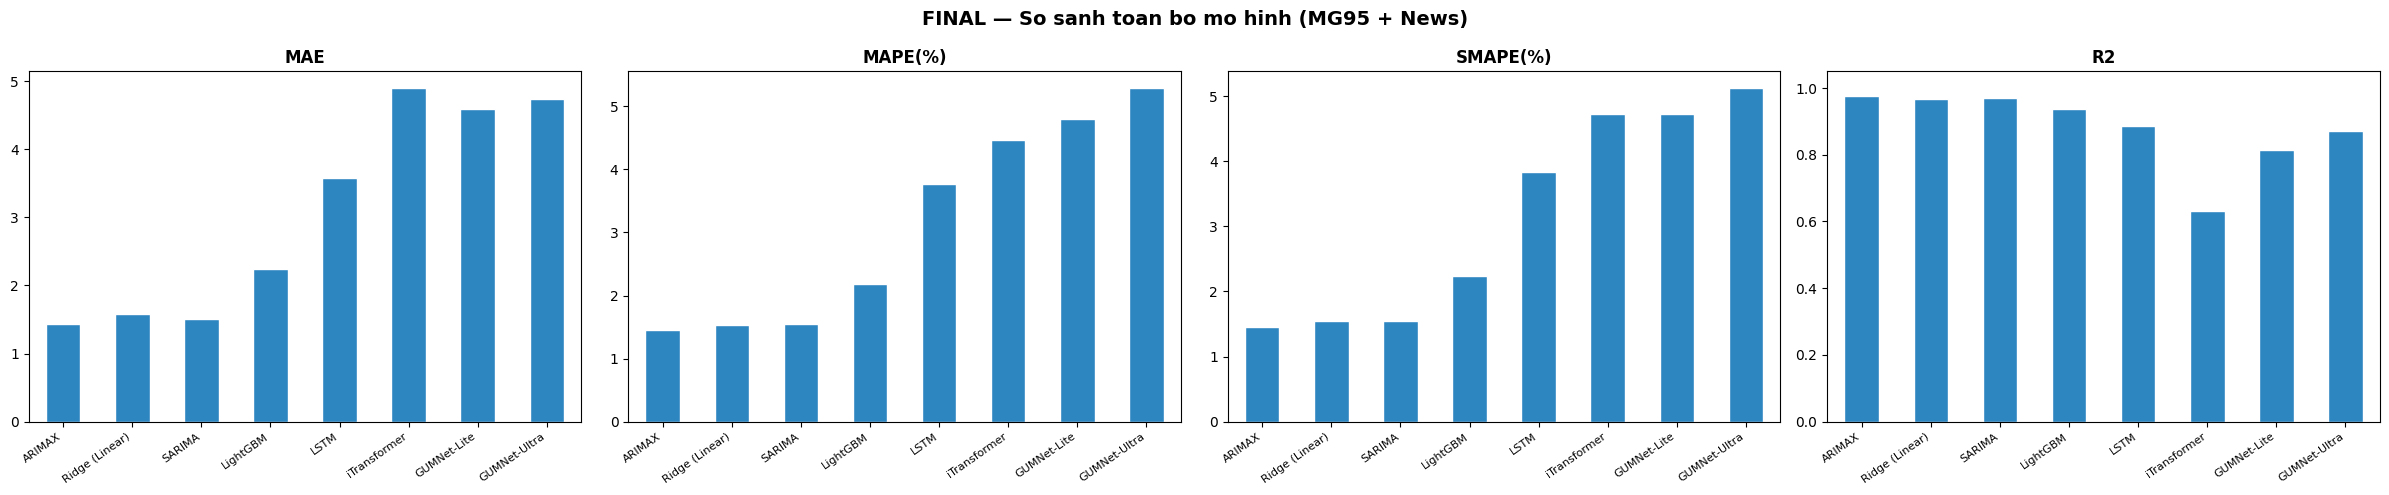

Saved -> results/model_comparison_final.csv + charts/model_comparison_final.png


In [ ]:
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results).set_index("Model").sort_values("MAPE(%)")
print("=== Regression (test:", test_dates.min().date(), "->", test_dates.max().date(), ") ===")
display(res_df)

(ROOT / "results" / "charts").mkdir(parents=True, exist_ok=True)
res_df.to_csv(ROOT / "results" / "model_comparison_final.csv")
if clf_results:
    print("\n=== Logistic (phan loai huong) ===")
    display(pd.DataFrame(clf_results).set_index("Model"))

mets = ["MAE", "MAPE(%)", "SMAPE(%)", "R2"]
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, m in zip(axes, mets):
    vals = res_df[m]
    vals.plot.bar(ax=ax, color="#2E86C1", edgecolor="white")
    ax.set_title(m, fontweight="bold"); ax.set_xlabel("")
    ax.set_xticklabels(res_df.index, rotation=35, ha="right", fontsize=8)
    if m == "R2": ax.set_ylim(min(0, float(vals.min())), 1.05)
plt.suptitle("FINAL — So sanh toan bo mo hinh (MG95 + News)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "results" / "charts" / "model_comparison_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> results/model_comparison_final.csv + charts/model_comparison_final.png")

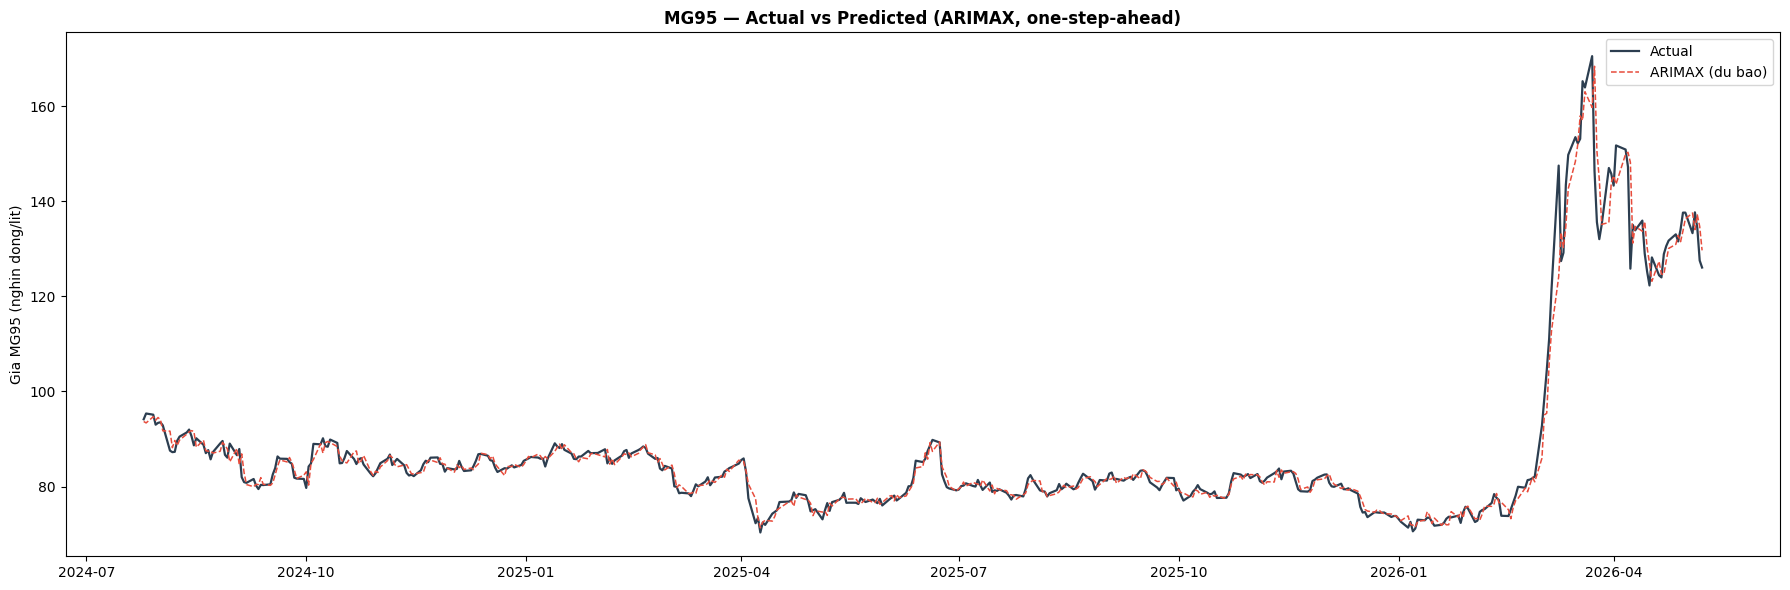

In [ ]:
# Actual vs Predicted tren tap test: uu tien model Jump-Gated neu da chay thanh cong.
if 'jump_result' in globals() and jump_result is not None:
    pred_df = jump_result["predictions"]
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(pred_df["date"], pred_df["actual"], color="#2C3E50", lw=1.6, label="Actual")
    ax.plot(pred_df["date"], pred_df["jump_gated"], color="#1F77B4", lw=1.1, ls="--", label="Jump-Gated ARIMAX-CatBoost")
    ax.set_title("MG95 - Actual vs Predicted (Jump-Gated ARIMAX-CatBoost)", fontweight="bold")
    ax.set_ylabel("Gia MG95 (nghin dong/lit)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(ROOT / "results" / "charts" / "actual_vs_pred_final.png", dpi=150, bbox_inches="tight")
    plt.show()
elif pred_ax is not None:
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(arima_dates, y_te_arima, color="#2C3E50", lw=1.6, label="Actual")
    ax.plot(arima_dates, pred_ax, color="#E74C3C", lw=1.1, ls="--", label="ARIMAX (du bao)")
    ax.set_title("MG95 - Actual vs Predicted (ARIMAX, one-step-ahead)", fontweight="bold")
    ax.set_ylabel("Gia MG95 (nghin dong/lit)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(ROOT / "results" / "charts" / "actual_vs_pred_final.png", dpi=150, bbox_inches="tight")
    plt.show()

## 14. Ghi chu cuoi

- **Tat ca mo hinh** danh gia one-step-ahead (H=1) tren cung tap test → so sanh cong bang.
- **Logistic Regression** la bai toan phan loai huong (Accuracy/F1), tach rieng khoi bang regression.
- **LSTM / iTransformer / GUMNet-Lite / GUMNet-Ultra** dung chung sliding-window tensors (`Xw_*`), target scale bang `scaler_y`, inverse khi tinh metric.
- **PatchTST / TFT** dung neuralforecast `cross_validation` (rolling 1-step).
- **Jump-Gated ARIMAX-CatBoost** la model hybrid tot nhat trong cac thu nghiem them: ARIMAX du bao nen, CatBoost sua sai so, va tang nhan dien ngay gia nhay manh.
- DL skip neu thieu `tensorflow` / `neuralforecast` — cai dat roi chay lai. Tang `dl_epochs`/`nf_steps` de chinh xac hon; doi `CONFIG['horizon']`=5/10 de test phan ra tin hieu (DL thuong an diem o horizon xa).
- Ket qua luu: `results/model_comparison_final.csv`, `results/charts/model_comparison_final.png`, `results/charts/actual_vs_pred_final.png`.